# 02 — Fitting a non-normalized, more realistic spectrum

A key strength of kinextract is that it does **not** require a pre-normalized spectrum.
Setting `fit_als_continuum=True` (default `False`) tells kinextract to co-fit a smooth
continuum baseline alongside the LOSVD, so you can pass raw flux-calibrated or even
raw-$\mathrm{erg/s/cm^2/\AA}$ spectra directly.

This notebook demonstrates the workflow on a synthetic galaxy spectrum built from a
**real stellar template** from the bundled MUSE library.  Stellar templates from
libraries (MILES, Indo-US, Cenarro et al., etc.) typically come in physical flux units
with a smooth stellar SED shape; before using them as fitting templates they should be
continuum-normalized so the continuum level ≈ 1 and absorption features dip below it.
We show that normalization step explicitly, then multiply the normalized template by a
synthetic galaxy continuum (**factor ~4 rise from blue to red** plus a broad hump) to
produce a realistic raw-$\mathrm{erg/s/cm^2/\AA}$ spectrum.  kinextract recovers the LOSVD without any
pre-normalization of the input galaxy spectrum.

**Key FitConfig option:** `fit_als_continuum = True`  (default `False`)

**Which continuum method?** `cfg.continuum_method` (default `"joint"`) selects *how* the
continuum baseline is estimated: `"joint"` folds a penalized-B-spline continuum directly
into the same single optimization as the LOSVD and template weights (see
`kinextract.joint`), and is the recommended default. This notebook explicitly sets
`continuum_method="als"` instead, because Section 6 demonstrates
`LOSVDErrorEstimator`'s bootstrap/Laplace error bars, which do not yet understand the
joint method's parameter layout (see `kinextract.joint`'s module docstring) -- `"als"`
and `"polynomial"` remain fully supported, opt-in alternatives for exactly this reason.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite

## 1. Load a real stellar template and normalize it

We start with `HD102212_av.dat` — a K-giant from the MUSE Library of Stellar Spectra, bundled with the
example data.  The raw file contains physical flux units, so the flux varies strongly
with wavelength (stellar SED shape).  We divide by a heavily-smoothed version of itself
($\sigma \approx 200 \mathrm{\AA}$) to estimate and remove the stellar continuum, leaving a spectrum where the
continuum level is ≈ 1 and the Ca II absorption features dip below it.

This is the same normalization step you would apply to any library template before
using it in kinextract.

In [2]:
# ── Load the raw stellar template ────────────────────────────────────────────
DATA_DIR  = Path('..') / 'data' / 'muse'
tmpl_data = np.loadtxt(DATA_DIR / 'HD102212_av.dat')
wavelength = tmpl_data[:, 0]          # 4749.65 - 9349.65 Å, step 1.25 Å
flux_raw   = tmpl_data[:, 1]          # physical flux (erg/s/cm²/Å)

N_PIX   = len(wavelength)
WAVEMIN = float(wavelength[0])        # 4749.65
STEP    = float(wavelength[1] - wavelength[0])   # 1.25

# ── Normalize by the stellar continuum ───────────────────────────────────────
# Heavy Gaussian smoothing ($\sigma$ = 160 pix ≈ 200 Å) averages over all narrow
# absorption features while preserving the broad SED shape — a good continuum
# estimate for a stellar spectrum.
smooth_cont = gaussian_filter(flux_raw, sigma=200)
template    = flux_raw / smooth_cont   # continuum ≈ 1; absorption features < 1

print(f"Raw template flux:     {flux_raw.min():.2e} - {flux_raw.max():.2e}  (physical units)")
print(f"Normalized template:   {template.min():.3f} - {template.max():.3f}  (continuum ≈ 1)")

Raw template flux:     3.61e-11 - 2.10e-10  (physical units)
Normalized template:   0.388 - 1.408  (continuum ≈ 1)


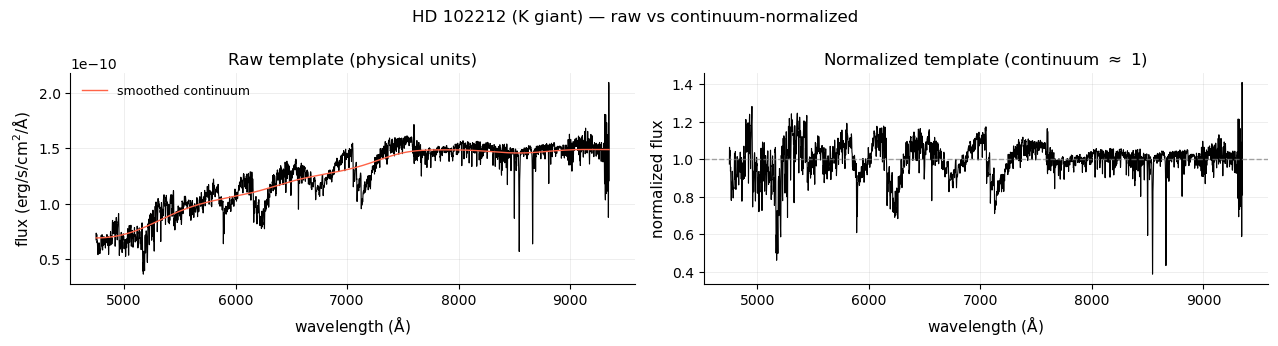

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharex=True)
fig.suptitle('HD 102212 (K giant) — raw vs continuum-normalized', fontsize=12)

ax = axes[0]
ax.plot(wavelength, flux_raw, lw=0.8, color='black')
ax.plot(wavelength, smooth_cont, lw=1.0, color='tomato', label='smoothed continuum')
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'flux ($\mathrm{erg/s/cm^2/\AA}$)')
ax.set_title(r'Raw template (physical units)')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(wavelength, template, lw=0.8, color='black')
ax.axhline(1.0, lw=1.0, color='grey', ls='--', alpha=0.7)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title(r'Normalized template (continuum $\approx$ 1)')

plt.tight_layout()
plt.show()

## 2. Build a synthetic galaxy spectrum with a complex continuum

We convolve the normalized template with a Gaussian LOSVD (V = +80 km/s, $\sigma$ = 140 km/s),
then multiply by a synthetic galaxy continuum — a cubic polynomial plus a broad Gaussian
hump, mimicking the overall shape of a cool-star-dominated galaxy SED.  This is the
spectrum kinextract will receive: raw $\mathrm{erg/s/cm^2/\AA}$, no prior normalization.

In [4]:
WAVEFITMIN, WAVEFITMAX = 8415.0, 8750.0
CEE, LAM_CENTER = 299792.458, 8580.0

TRUE_V     =  80.0   # km/s
TRUE_SIGMA = 140.0   # km/s

# ── Convolve normalized template with the true LOSVD ─────────────────────────
sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
RNG       = np.random.default_rng(42)
gal_norm  = ndimage_shift(gaussian_filter(template, sigma_pix), +shift_pix)

# ── Galaxy continuum: cubic polynomial + broad Gaussian hump ─────────────────
# x_norm ∈ [-1, +1] across the full wavelength range.
# Produces a factor ~4 rise from blue to red with a broad hump near 7700 Å,
# roughly matching the SED of a cool-star-dominated galaxy.
# Include a small sinusoidal fringe pattern to mimic imperfect flat-fielding.

CONT_LEVEL = 12_000.0
x_norm = (wavelength - wavelength.mean()) / (0.5 * (wavelength[-1] - wavelength[0]))
slope  = 1.0 + 0.80 * x_norm + 0.5 * x_norm**2 - 0.10 * x_norm**3
hump   = 0.50 * np.exp(-0.5 * ((x_norm - 0.20) / 0.45)**2)
fringes = 0.01 * np.sin(2 * np.pi * (wavelength - wavelength[0]) / 50.0)
cont   = CONT_LEVEL * (slope + hump + fringes)

gal   = gal_norm * cont
NOISE = 250.0
gal  += RNG.normal(0.0, NOISE, N_PIX)
errs  = np.full(N_PIX, NOISE)

cat_mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
print(f"Galaxy continuum range:  {cont.min():.0f} - {cont.max():.0f}  erg/s/cm^2/angstrom$")
print(f"S/N in fit window:       "
      f"{cont[cat_mask].min() / NOISE:.0f} - {cont[cat_mask].max() / NOISE:.0f}")

# ── Save spectrum and normalized template to a temp directory ─────────────────
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_cont_'))
spec_path = tmpdir / 'mock_cont.spec'
tmpl_path = tmpdir / 'mock_template.dat'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX + 1), gal, errs]),
           fmt='%6d  %14.4f  %14.4f')
np.savetxt(tmpl_path, np.column_stack([wavelength, template, np.full(N_PIX, 0.001)]),
           fmt='%10.4f  %14.8f  %12.8f')
(tmpdir / 'Tlist').write_text('mock_template.dat\n')
print(f"Files written to {tmpdir}")

Galaxy continuum range:  9162 - 27636  erg/s/cm^2/angstrom$
S/N in fit window:       94 - 99
Files written to /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_cont_i0qm9g40


(8326.823590640983, 30124.561754554677)

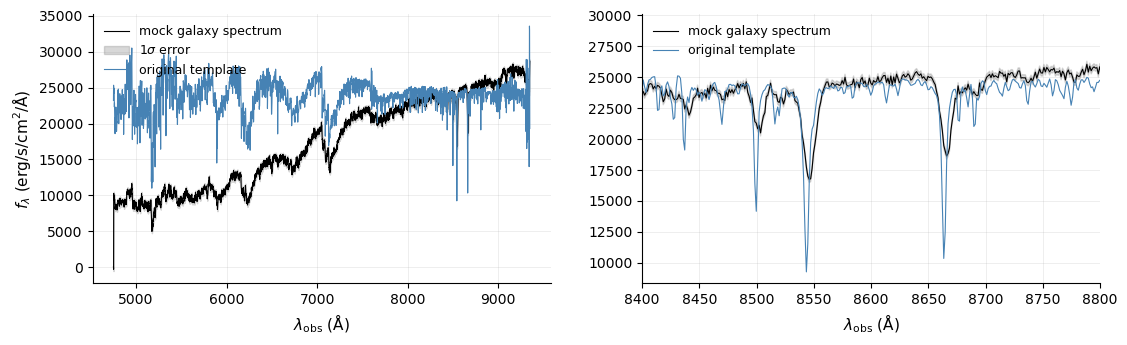

In [5]:
fig, ax = plt.subplots(1,2, figsize=(13, 3.5))
plot_template = template * np.median(gal[(wavelength >= 8000) & (wavelength <= 9000)])
ax[0].plot(wavelength, gal, lw=0.8, color='black', label='mock galaxy spectrum')
ax[0].fill_between(wavelength, gal - errs, gal + errs, color='grey', alpha=0.3, label=r'$1\sigma$ error')
ax[0].plot(wavelength, plot_template, lw=0.8, color='steelblue', label='original template')
ax[0].set_xlabel(r'$\lambda_\mathrm{obs}$ ($\mathrm{\AA}$)')
ax[0].set_ylabel(r'$f_\lambda$ ($\mathrm{erg/s/cm^2/\AA}$)')
ax[0].legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)

ax[1].plot(wavelength, gal, lw=0.8, color='black', label='mock galaxy spectrum')
ax[1].fill_between(wavelength, gal - errs, gal + errs, color='grey', alpha=0.3)
ax[1].plot(wavelength, plot_template, lw=0.8, color='steelblue', label='original template')
ax[1].set_xlabel(r'$\lambda_\mathrm{obs}$ ($\mathrm{\AA}$)')
ax[1].legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)

ax[1].set_xlim(8400, 8800)
ax[1].set_ylim(0.9 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].min(), 
                1.2 * plot_template[(wavelength >= 8400) & (wavelength <= 8800)].max())

## 3. Fit with `fit_als_continuum = True`

Setting `fit_als_continuum=True` tells kinextract to estimate and remove the smooth
continuum inside the fitting loop.  The galaxy spectrum passed in has raw $\mathrm{erg/s/cm^2/\AA}$ with
the complex continuum intact — no pre-normalization is needed.  The normalized template
saved above is used directly as the fitting template.

`continuum_method="als"` is set explicitly below (rather than relying on the `"joint"`
default) so this notebook's Section 6 bootstrap/Laplace error bars work -- see the intro
note above.

In [ ]:
cfg = FitConfig(
    template_list_file  = str(tmpdir / 'Tlist'),
    template_dir        = str(tmpdir),
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    zgal                = 0.0,
    fit_als_continuum   = True,          # <-- key option
    continuum_method    = "als",         # see intro note: needed for Section 6's error bars
    use_spectrum_errors = True,
    xlam_auto           = True,
    losvd_vmin          = -500.0,        # km/s
    losvd_vmax          = +500.0,        # km/s
    sigl                = 100.0,
    clean               = False,
    map_maxiter         = 10000,
    print_every         = 999999,
)

fit = run_spectral_fit(cfg, gal_file=str(spec_path))
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chisquared_reduced = {out['chi2_red']:.3f}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

## 4. Extract GH moments from the recovered LOSVD

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"Recovered:  V = {gh['vherm']:+.1f}  sigma = {gh['sherm']:.1f}  "
      f"h3 = {gh['h3']:+.4f}  h4 = {gh['h4']:+.4f}")
print(f"Truth:      V = {TRUE_V:+.1f}  sigma = {TRUE_SIGMA:.1f}")

Recovered:  V = +78.7  sigma = 134.5  h3 = -0.0072  h4 = +0.0050
Truth:      V = +80.0  sigma = 140.0


## 5. Diagnostic plots

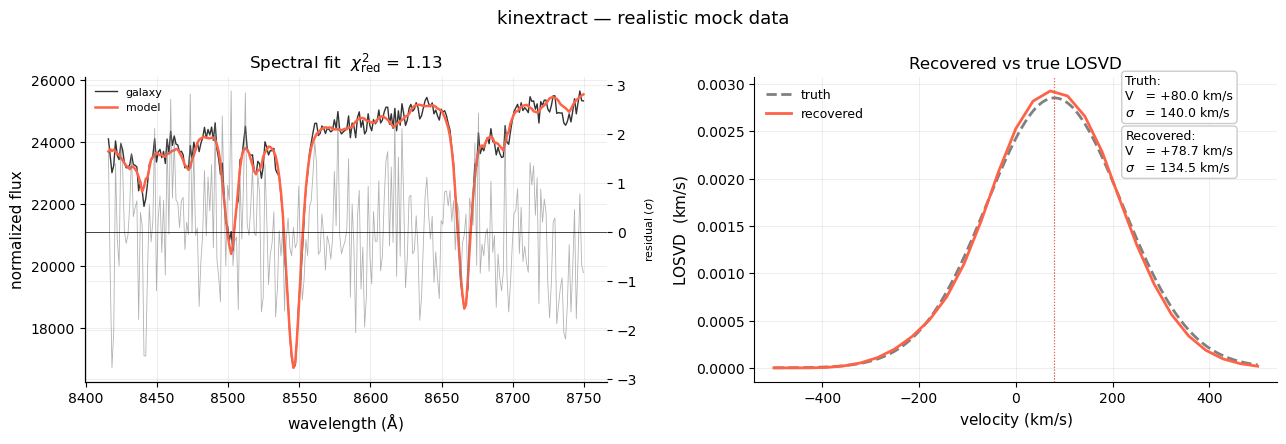

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — realistic mock data', fontsize=13)

# ── Panel 1: normalized residual ─────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'normalized flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
v_true = np.linspace(cfg.losvd_vmin, cfg.losvd_vmax, 401)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= trapezoid(b_true, v_true)
b_rec   = b / trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,       lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'],  lw=0.8, color='tomato', ls=':')


ax.text(0.71, 0.86,
        f"Truth:\n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.text(0.71, 0.68,
        f"Recovered:\n"
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel(r'velocity ($\mathrm{km/s}$)')
ax.set_ylabel(r'LOSVD  ($\mathrm{km/s}$)')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin-40, cfg.losvd_vmax+40)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated two complementary ways:

- **Laplace / penalized-likelihood covariance** (fast, ~seconds): inverts a finite-difference Hessian of the MAP objective at the best-fit solution to get an approximate posterior covariance. Cheap and always worth running first, but likely underestimates true errors if the noise model or regularization strength is imperfect.
- **Residual bootstrap** (more thorough, slower): resamples fit residuals into synthetic spectra and refits each through the same MAP machinery -> an independent, frequentist cross-check that doesn't rely on the Laplace approximation. Slower since each of N_BOOT replicates is a full refit.

In [9]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
laplace = est.laplace_covariance()
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=1)
summary = est.summarize(laplace_result=laplace, bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Recommended uncertainties (bootstrap preferred over Laplace when both available):")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Computing Hessian...
[LOSVDErrors] Using JAX gradient-backed Hessian FD (CPU)


/var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/ipykernel_20755/3310796191.py:6: RuntimeWarning: Laplace covariance: the largest projected gradient component at the MAP solution is 0.412, above grad_warn_threshold=0.05. This suggests the MAP optimization did not fully converge, which can make the Hessian indefinite and the resulting error bars unreliable (some may be silently near-zero). Consider tightening map_ftol/map_gtol or enabling use_jax_objective before re-fitting.
  laplace = est.laplace_covariance()


[LOSVDErrors] Laplace covariance done in 0.3s. Hessian PD (free params): True. Pinned: 2/29 LOSVD bins, 1/1 template weights. Max projected |grad|: 0.412
[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=1)...


[LOSVDErrors] Bootstrap 5/50 (5s elapsed)


[LOSVDErrors] Bootstrap 10/50 (10s elapsed)


...

[LOSVDErrors] Bootstrap 30/50 (33s elapsed)


[LOSVDErrors] Bootstrap 35/50 (38s elapsed)


[LOSVDErrors] Bootstrap 40/50 (43s elapsed)


[LOSVDErrors] Bootstrap 45/50 (48s elapsed)


[LOSVDErrors] Bootstrap 50/50 (52s elapsed)
[LOSVDErrors] Bootstrap done in 52.3s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +78.70 km/s ± 2.99
    σ    = 134.53 km/s ± 2.45
    h3   = -0.0072 ± 0.0166
    h4   = +0.0050 ± 0.0145
  LOSVD moments (for reference):
    V    = +77.20 km/s ± 3.86
    σ    = 140.42 km/s ± 5.43

  Bootstrap: 50 successful / 50 total replicates

Recommended uncertainties (bootstrap preferred over Laplace when both available):
  V     = +78.70 km/s ± 2.99
  σ     = +134.53 km/s ± 2.45
  h3    = -0.01 ± 0.02
  h4    = +0.01 ± 0.01


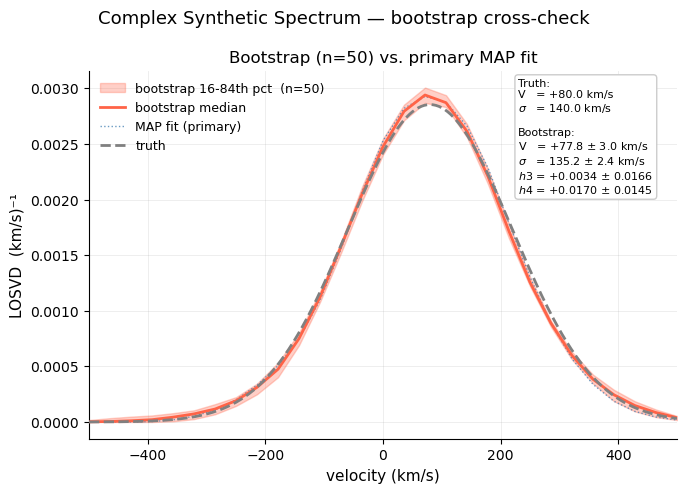

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Complex Synthetic Spectrum — bootstrap cross-check', fontsize=13)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

bs       = np.array(boot['b_samples'])
bs_traps = np.array([trapezoid(s, st.xl) for s in bs])[:, np.newaxis]
bs       = bs / bs_traps
b_median = np.median(bs, axis=0)
b_lo     = np.maximum(np.percentile(bs, 16, axis=0), 0.0)
b_hi     = np.percentile(bs, 84, axis=0)
gh_med   = fit_losvd_gauss_hermite(st.xl, b_median, fit_h3h4=True)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap 16-84th pct  (n={N_BOOT})')
ax.plot(st.xl, b_median, lw=2.0, color='tomato', zorder=5, label='bootstrap median')
ax.plot(st.xl, b_norm, lw=1.0, ls=':', color='steelblue', alpha=0.8, label='MAP fit (primary)')
ax.plot(v_true, b_true, lw=2.0, color='grey', ls='--', label='truth', zorder=5)

ax.text(0.73, 0.66,
        f"Truth:           \n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s\n\n"
        f"Bootstrap:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'Bootstrap (n={N_BOOT}) vs. primary MAP fit')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()